In [3]:
import evolml
import numpy as np
import matplotlib.pyplot as plt
import seaborn_image as isns

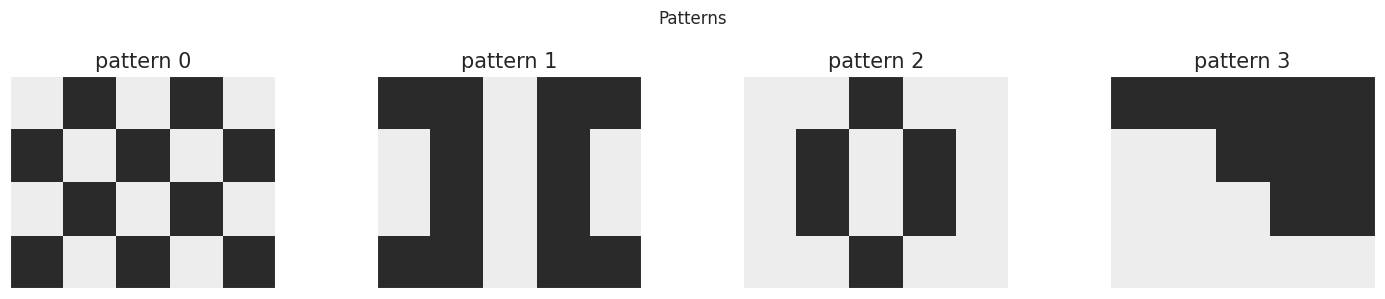

In [30]:
patterns = [
    np.tile([1,-1], 10),
    np.array([-1,-1, 1,-1,-1, 1,-1, 1,-1, 1, 1,-1, 1,-1, 1,-1,-1, 1,-1,-1]),
    np.array([ 1, 1,-1, 1, 1, 1,-1, 1,-1, 1, 1,-1, 1,-1, 1, 1, 1,-1, 1, 1]),
    np.array([-1,-1,-1,-1,-1, 1, 1,-1,-1,-1, 1, 1, 1,-1,-1, 1, 1, 1, 1, 1]),
]

X = np.vstack(patterns)

imggrid = isns.ImageGrid(X.reshape((-1,4,5)).transpose((1,2,0)), cbar=False, cmap="Greys_r", vmin=-1.4, vmax=1.4, col_wrap=X.shape[0])
imggrid.fig.suptitle("Patterns")
for i, ax in enumerate(imggrid.axes.flatten()):
    ax.set_title(f"pattern {i}")
imggrid.fig.tight_layout()

In [31]:
model = evolml.models.BernoulliHopfieldNetwork(iterations=100)
model.fit(X)

BernoulliHopfieldNetwork(iterations=100)

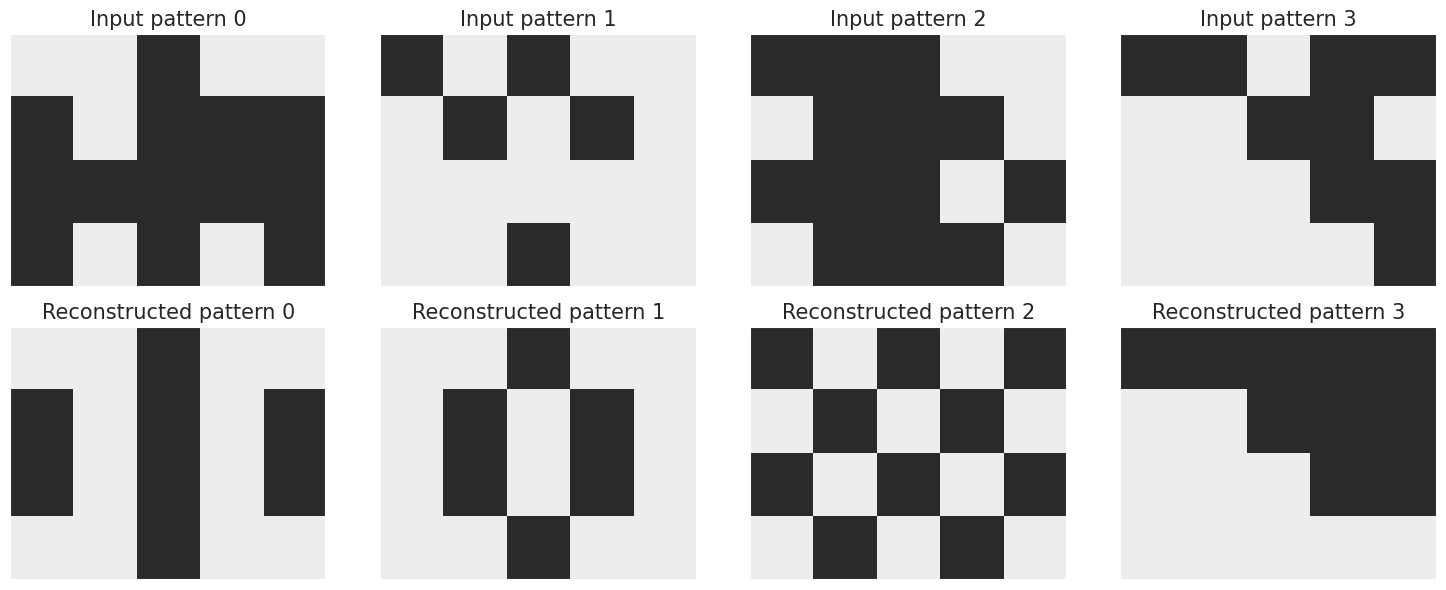

In [66]:
X_test = np.asarray([
    [ 1, 1,-1, 1, 1,-1, 1,-1,-1,-1,-1,-1,-1,-1,-1,-1, 1,-1, 1,-1],
    [-1, 1,-1, 1, 1, 1,-1, 1,-1, 1, 1, 1, 1, 1, 1, 1, 1,-1, 1, 1],
    [-1,-1,-1, 1, 1, 1,-1,-1,-1, 1,-1,-1,-1, 1,-1, 1,-1,-1,-1, 1],
    [-1,-1, 1,-1,-1, 1, 1,-1,-1, 1, 1, 1, 1,-1,-1, 1, 1, 1, 1,-1],
])
pred_test = model.transform(X_test)

disp_patterns = np.vstack([X_test.reshape((-1,4,5)),pred_test.reshape((-1,4,5))]).transpose((1,2,0))

imggrid = isns.ImageGrid(disp_patterns, cmap="Greys_r", cbar=False, col_wrap=X_test.shape[0], vmin=-1.4, vmax=1.4)

for i, ax in enumerate(imggrid.axes.T):
    ax[0].set_title(f"Input pattern {i}")
    ax[1].set_title(f"Reconstructed pattern {i}")

imggrid.fig.tight_layout()

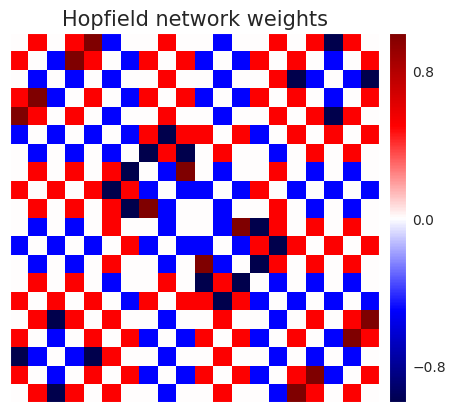

In [67]:
imgplot = isns.imgplot(model.coef_, cmap="seismic", diverging=True)
imgplot.set_title("Hopfield network weights")
plt.show()

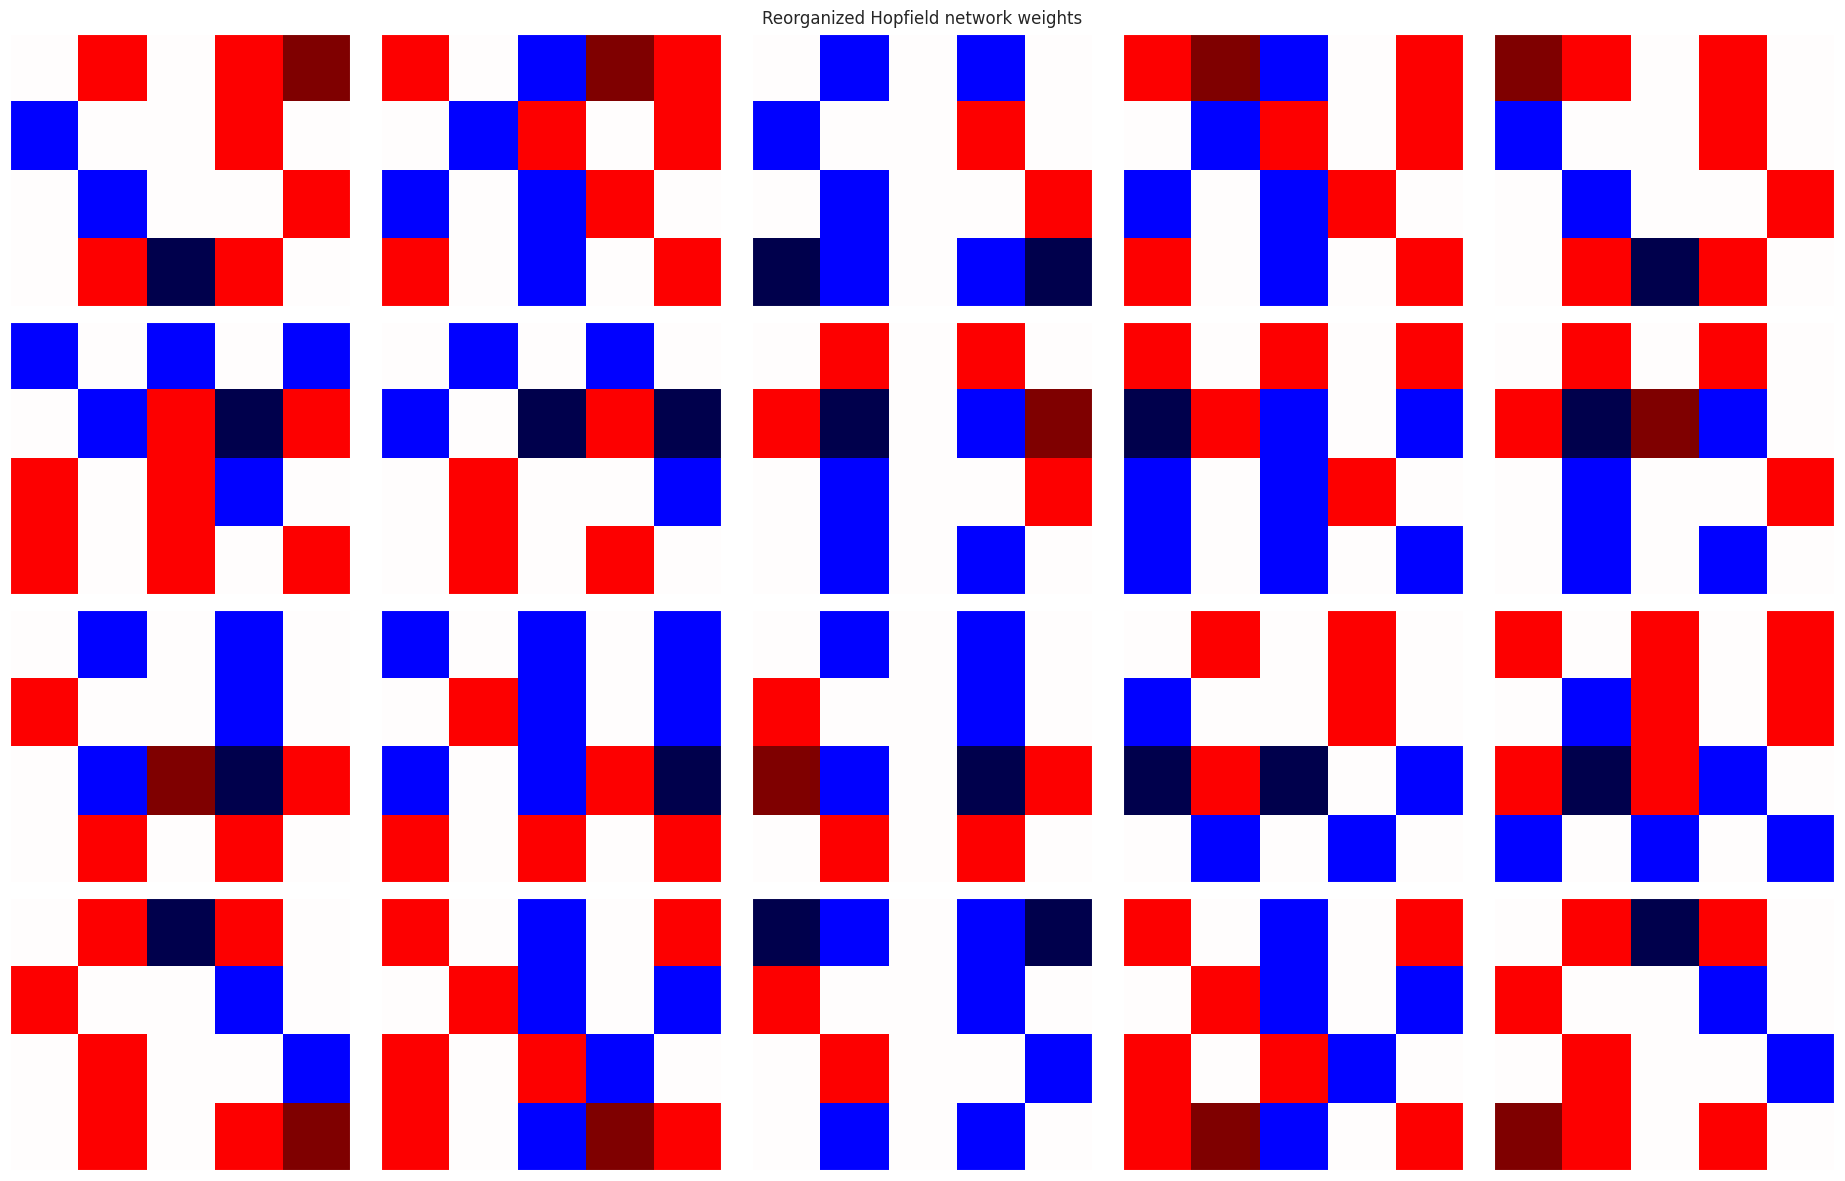

In [68]:
imggrid = isns.ImageGrid(model.coef_[None,:,:].reshape((4,5,-1)), cbar=False, cmap="seismic", diverging=True, col_wrap=5)
imggrid.fig.suptitle("Reorganized Hopfield network weights")
imggrid.fig.tight_layout()
plt.show()